<a href="https://colab.research.google.com/github/sonjoy1s/LungCancer/blob/main/LungCancerForPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [22]:
base_path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", base_path)

Using Colab cache for faster access to the 'lung-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-cancer-histopathological-images


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [24]:
categories = ['adenocarcinoma','benign','squamous_cell_carcinoma']

In [25]:
images = []
labels = []

# Iterate through each category to build paths
for cls in categories:
    cls_path = os.path.join(base_path, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        images.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': images,
    'label': labels
})

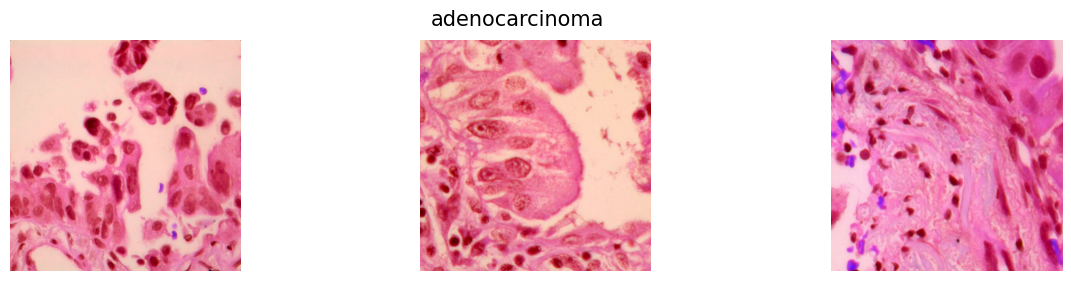

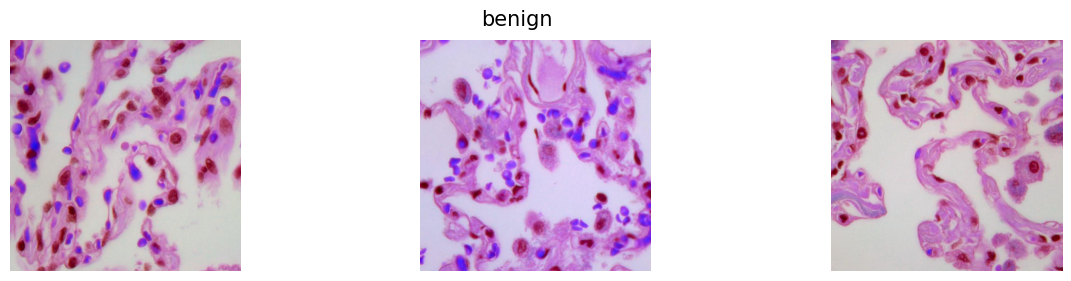

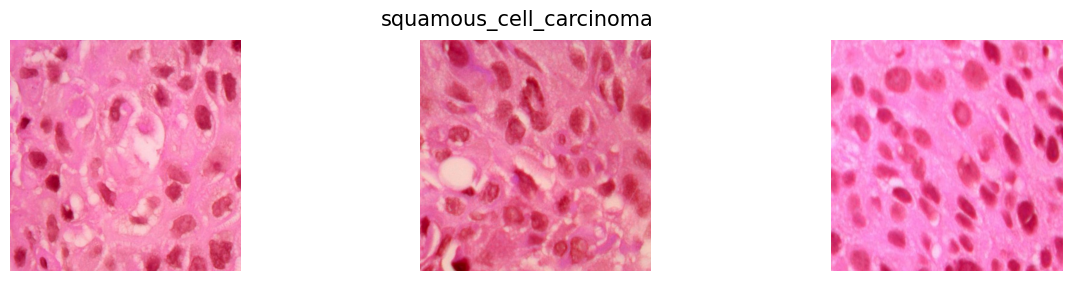

In [26]:
import cv2
import matplotlib.pyplot as plt
for cat in categories:
    # Construct the full path for the current category
    category_path = os.path.join(base_path, cat)
    images = os.listdir(category_path)
    # Initialize a subplot with 1 row and 3 columns
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    fig.suptitle(f'{cat}', fontsize=15)

    for i in range(3):
        # Randomly select an image
        img_name = images[np.random.randint(0, len(images))]
        img_path = os.path.join(category_path, img_name)
        img_array = cv2.imread(img_path)

        # Display the image
        ax[i].imshow(img_array)
        ax[i].axis('off')

In [27]:
df['label_id'], uniques = pd.factorize(df['label'])
#df['image_path'],uniques = pd.factorize(df['image'])
print("Class Names:", uniques.tolist())

Class Names: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']


In [28]:
X_train,X_test= train_test_split(df['label_id'],test_size=0.2,random_state=42)

In [29]:
X_train

,label_id
9839,1
9680,1
7093,1
11293,2
820,0
...,...
5191,1
13418,2
5390,1
860,0


In [30]:
transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5)*3,std=(0.5)*3)
    ]
)

In [31]:
from genericpath import isfile

class MyCustomeData(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe['image'].values
        self.labels = dataframe['label_id'].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")

        label = int(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label

In [51]:
import cv2
import numpy as np

def preprocess_image(image_path):

    img = cv2.imread(image_path)

    # Resize
    img = cv2.resize(img, (128,128))

    # Noise reduction
    img = cv2.GaussianBlur(img, (5,5), 0)

    # Convert to grayscale
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # CLAHE enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    # Normalize
    enhanced = enhanced / 255.0

    return enhanced

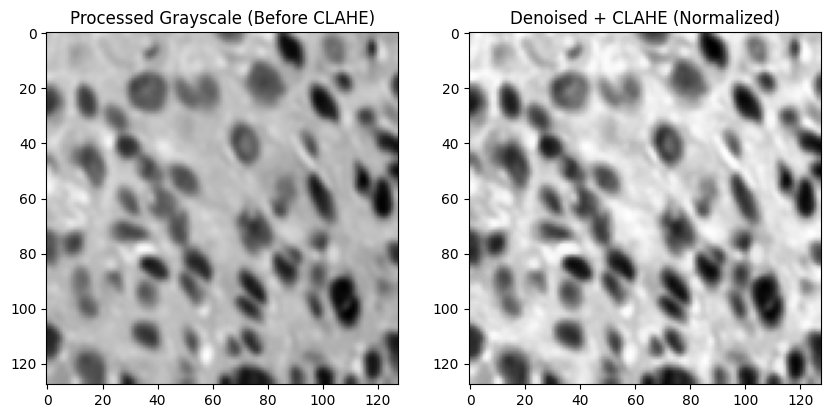

In [52]:
import cv2
if 'img_path' not in locals() or img_path is None:
    if 'df' in globals() and not df.empty:
        img_path = df['image'].iloc[0]
    else:
        # Fallback if df is not available or empty
        print("No image path available. Please ensure 'df' and 'img_path' are defined.")
        # You might want to return or raise an error here if no image can be loaded
        raise ValueError("Cannot display images without a valid image path.")

# Load the image
sample_img_raw = cv2.imread(img_path)

# Apply resize and gaussian blur as done internally by preprocess_image for the 'gray' comparison
resized_img = cv2.resize(sample_img_raw, (128, 128))
blurred_img = cv2.GaussianBlur(resized_img, (5, 5), 0)

# Convert to grayscale to get 'gray'
gray = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)

# Get the enhanced image by calling the preprocess_image function
enhanced = preprocess_image(img_path)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(gray, cmap='gray')
ax[0].set_title("Processed Grayscale (Before CLAHE)")

ax[1].imshow(enhanced, cmap='gray')
ax[1].set_title("Denoised + CLAHE (Normalized)")

plt.show()

In [32]:
train_dataset_full = MyCustomeData(df.loc[X_train.index], transform)
test_dataset_full = MyCustomeData(df.loc[X_test.index], transform)
num_classes = len(uniques)

print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full test size:", len(test_dataset_full))

Number of classes: 3
Full train size: 12000
Full test size: 3000


In [33]:
train_dataset = Subset(train_dataset_full, list(range (0, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, list(range(0, len(test_dataset_full))))

In [ ]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

In [35]:
pin = True if device.type == 'cuda' else False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=pin)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=pin)

In [36]:
class MyCNNs(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [37]:
model = MyCNNs(num_classes=num_classes).to(device)

In [40]:
learning_rate = 0.001
epochs = 10
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [41]:
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 0.6715
Epoch 2/10, Loss: 0.5472
Epoch 3/10, Loss: 0.5121
Epoch 4/10, Loss: 0.4784
Epoch 5/10, Loss: 0.4526
Epoch 6/10, Loss: 0.4431
Epoch 7/10, Loss: 0.4242
Epoch 8/10, Loss: 0.4240
Epoch 9/10, Loss: 0.4098
Epoch 10/10, Loss: 0.4009


In [58]:
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

In [43]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)
train_acc = evaluate(train_loader)
print("Train Accuracy:", train_acc)


Test Accuracy: 0.9833333333333333
Train Accuracy: 0.99475


In [44]:
from sklearn.metrics import confusion_matrix

def get_all_preds(loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_all_preds(test_loader)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[1021    0   16]
 [   0  970    0]
 [  34    0  959]]


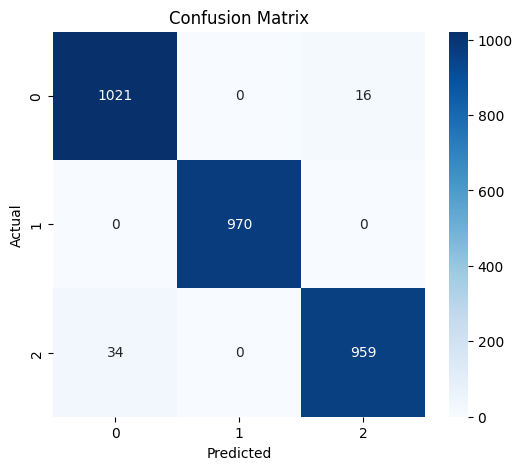

In [45]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [46]:
from sklearn.metrics import classification_report,roc_auc_score
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1037
           1       1.00      1.00      1.00       970
           2       0.98      0.97      0.97       993

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



In [49]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class='ovr'
)

print("AUC:", auc)

AUC: 0.9973069010942334


torch.Size([24, 32, 128, 128])


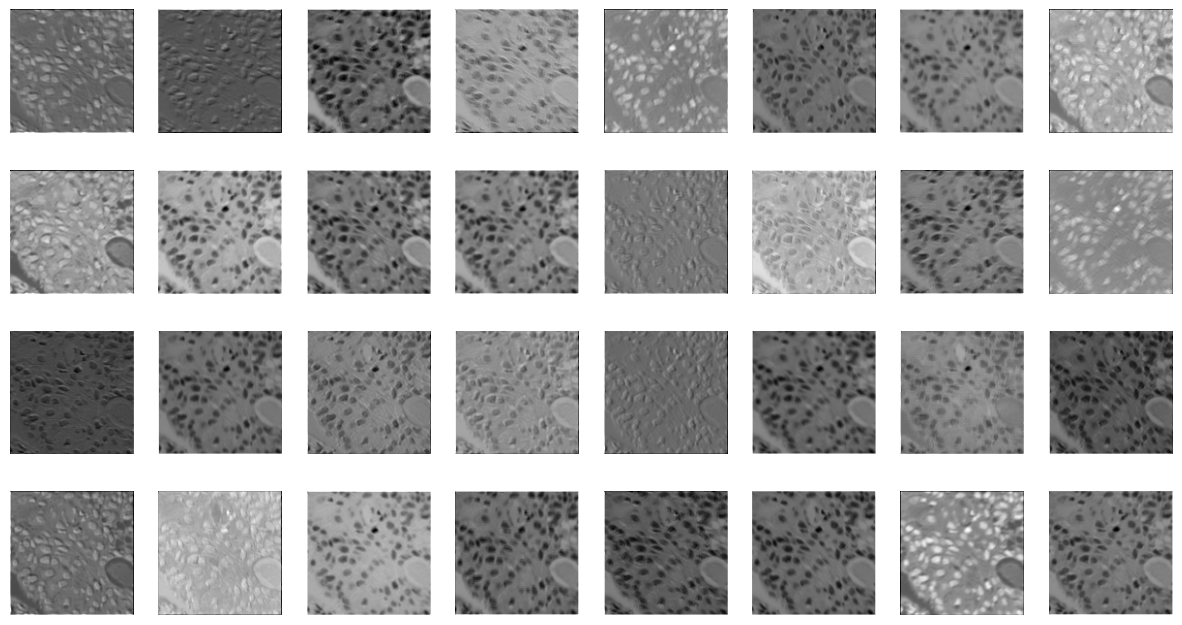

In [64]:
feature_map = model.features[0](images)
print(feature_map.shape)

fig, axes = plt.subplots(4,8, figsize=(15,8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        feature_map[0,i].detach().cpu().numpy(),
        cmap='gray'
    )

    ax.axis('off')

plt.show()